Final weights:  [0.4 0.4]
Final biase:  -0.5999999999999999
Predicted value:  [0, 0, 0, 1]


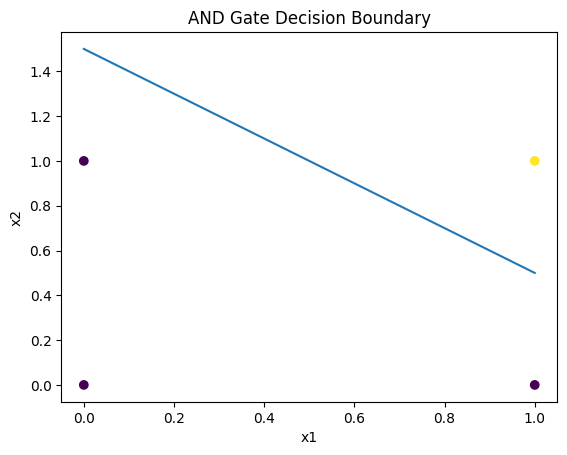

In [7]:
import numpy as np
import matplotlib.pyplot as plt

X=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y=np.array([0,0,0,1])
#if value greater than 0 means positive return 1 if value is negative return 0 simpply
def step_function(z):
    if z>=0:
        return 1
    else:
        return 0

#next is prediction function
def predict(X,W,B):#here X is input layers like 0 0 or 0 1 ,1 0 and 1 1 and W is weights  for both inputs
 #and B is biase
    actual_values=[]
    for n in X:
        z=np.dot(n,W)+b   # here is dot product implement like z=x1w1+x2w2+b
        #after finding this we perform activiation funciton on it here function is step_funciton
        y_new=step_function(z)
        actual_values.append(y_new)
    return actual_values

def train_perceptron(X, y, epochs=10, learning_rate=0.1):
    n_features = X.shape[1]#shape for weights , if two values then two weights if three then w according to it

    weights = np.ones(n_features)#  initiase all weights with 1 [1,1]
    bias = 1 # also biase with one

    for x in range(epochs):#here 10 iteratikons work
        for i in range(len(X)):
            x = X[i]#values at 0th  row in
            target = y[i] #desired value of y
            #after gettin x 0th row and and weights
            #z=x1w1+x2w2+b
            z = np.dot(x, weights) + bias
            #apply step funciton
            y_pred = step_function(z)
            #find error desired value - actual value
            error = target - y_pred
            #update weights equation is w=w+learningRate*error*x values
            #if two x values then two weights will return if three then three weihts
            weights = weights + learning_rate * error * x
            #update biasae
            #b=b+ learningRate*error
            bias = bias + learning_rate * error

    return weights, bias

def plot_decision_boundary(X, y, weights, bias, title):
    #draw line for x1 and x2 values we take 100 x_values between 0 and 1 and draw line for equation of y
    plt.scatter(X[:,0], X[:,1], c=y)

    x_one = np.linspace(0,1,100)#take 100 values between 0 and 1
    if weights[1] != 0:#if weights not zero
        # as we now z=x1w1+x2w2+b from this equaiton we take x2 values that are calcuated by rearrange formula
        x_two = -(weights[0]*x_one + bias) / weights[1]
        plt.plot(x_one, x_two)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()
w1_w2, b = train_perceptron(X, y, epochs=10)# this will run 10 times and get final weight and biase values after 10 iterations

print("Final weights: ",w1_w2)
print("Final biase: ", b)

predicted_value=predict(X,w1_w2,b)
print("Predicted value: ",predicted_value)#these values are same as y values we want so error is zero

plot_decision_boundary(X, y, w1_w2, b, "AND Gate Decision Boundary")

In [8]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
print(X)
print(y)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 

In [9]:
#part 2
from sklearn.datasets import load_breast_cancer
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X, y = load_breast_cancer(return_X_y=True)
#values of x and y after loading
print(X)
print(y)

X, y = make_classification(
n_samples=1000,
n_features=2,
n_informative=2,
n_redundant=0,
n_repeated=0,
n_classes=2,
random_state=42
)
#after classification we split our dataset in train and test format 20 percent for test and 80 per train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

 # scaling that fit mean 0 and std 1 and this is x-mean/std
#that is standarization feature technique

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#train model using keras sequential as you given this in lab manual

model = tf.keras.Sequential([
tf.keras.Input(shape=(2,)),
tf.keras.layers.Dense(1, activation='sigmoid')])#sigmoid function will applied as a activation funciton on output
#compile our model
#this will run 50 epoches means iterations and train model
model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy'])
#fit model
history = model.fit(X_train, y_train,
epochs=50,
batch_size=16,
validation_split=0.1)

#after training model evaluate our model
results = model.evaluate(X_test, y_test, verbose=0)
print(results)#find resutls after evealuteing on test data

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 